# LAS REDES SOCIALES A TRAVES DE LAS DISTINTAS GENERACIONES





### Objetivo del Informe EDA
Evaluar el uso de redes sociales a traves de distintas generaciones. Se busca demostrar como la edad es determinante para  la relacion de los usuarios con las plataformas digitales, analizando metricas de productividad, estres, ansiedad y toxicidad.



#### HIPOTESIS 1
Los nativos digitales (Gen Z/Alfa)  A pesar de nacer hiperconectados, el uso intensivo les genera niveles mas altos de ansiedad y disrupciones de sueño que a los adultos.

#### HIPOTESIS 2

Los Millennials y Boomers experimentan una dependencia distinta. Dicen usarlos menos y no tener las consecuencias que tienen los jovenes.


#### HIPOTESIS 3


La forma en que se manifiesta la toxicidad digital depende de la generacion y la plataforma.

# 1. IMPORTACIÓN Y LIMPIEZA

Cargar el dataset y  limpieza de valores nulos. Despues de limpiar los datos, mantenemos 17,074 registros limpios, los cuales son suficientes."

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

direccion = 'datos/Social Media vs Productivity/social_media_vs_productivity.csv'
smp = pd.read_csv(direccion)
smp_limpio = smp.dropna().copy()
smp_limpio.info() 

<class 'pandas.DataFrame'>
Index: 17074 entries, 0 to 29998
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   edad                             17074 non-null  int64  
 1   genero                           17074 non-null  str    
 2   tipo_trabajo                     17074 non-null  str    
 3   tiempo_diario_redes_sociales     17074 non-null  float64
 4   plataforma_preferida             17074 non-null  str    
 5   numero_notificaciones            17074 non-null  int64  
 6   horas_trabajo_dia                17074 non-null  float64
 7   puntaje_productividad_percibida  17074 non-null  float64
 8   puntaje_productividad_real       17074 non-null  float64
 9   nivel_estres                     17074 non-null  float64
 10  horas_sueno                      17074 non-null  float64
 11  tiempo_pantalla_antes_sueno      17074 non-null  float64
 12  descansos_durante_trabajo        1


# # CONTEXTO GENERAL

In [15]:
smp.info()

<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 19 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   edad                             30000 non-null  int64  
 1   genero                           30000 non-null  str    
 2   tipo_trabajo                     30000 non-null  str    
 3   tiempo_diario_redes_sociales     27235 non-null  float64
 4   plataforma_preferida             30000 non-null  str    
 5   numero_notificaciones            30000 non-null  int64  
 6   horas_trabajo_dia                30000 non-null  float64
 7   puntaje_productividad_percibida  28386 non-null  float64
 8   puntaje_productividad_real       27635 non-null  float64
 9   nivel_estres                     28096 non-null  float64
 10  horas_sueno                      27402 non-null  float64
 11  tiempo_pantalla_antes_sueno      27789 non-null  float64
 12  descansos_durante_trabajo    

In [16]:
smp_limpio.describe()

,edad,tiempo_diario_redes_sociales,numero_notificaciones,horas_trabajo_dia,puntaje_productividad_percibida,puntaje_productividad_real,nivel_estres,horas_sueno,tiempo_pantalla_antes_sueno,descansos_durante_trabajo,consumo_cafe_dia,dias_burnout_mes,horas_desconexion_semanal,puntaje_satisfaccion_laboral
count,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000,17074.000000
mean,41.462926,3.122575,59.974288,6.989841,5.505523,4.944530,5.512592,6.506391,1.025165,5.001113,2.004803,15.540119,10.369978,4.945884
std,13.835084,2.080257,7.788587,1.995280,2.026415,1.888881,2.866152,1.455486,0.654821,3.183056,1.409725,9.240403,7.253499,2.130109
min,18.000000,0.000000,32.000000,0.000000,2.000252,0.298476,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,1.647730,55.000000,5.661512,3.745743,3.352817,3.000000,5.503544,0.526338,2.000000,1.000000,8.000000,4.605728,3.319909
50%,41.000000,3.036425,60.000000,6.985661,5.515816,4.936777,6.000000,6.510388,1.010674,5.000000,2.000000,16.000000,10.010172,4.941100
75%,53.000000,4.367746,65.000000,8.347780,7.259461,6.531210,8.000000,7.492182,1.473942,8.000000,3.000000,24.000000,15.306980,6.584756
max,65.000000,17.817948,90.000000,12.000000,8.999376,9.846258,10.000000,10.000000,3.000000,10.000000,9.000000,31.000000,40.964769,10.000000


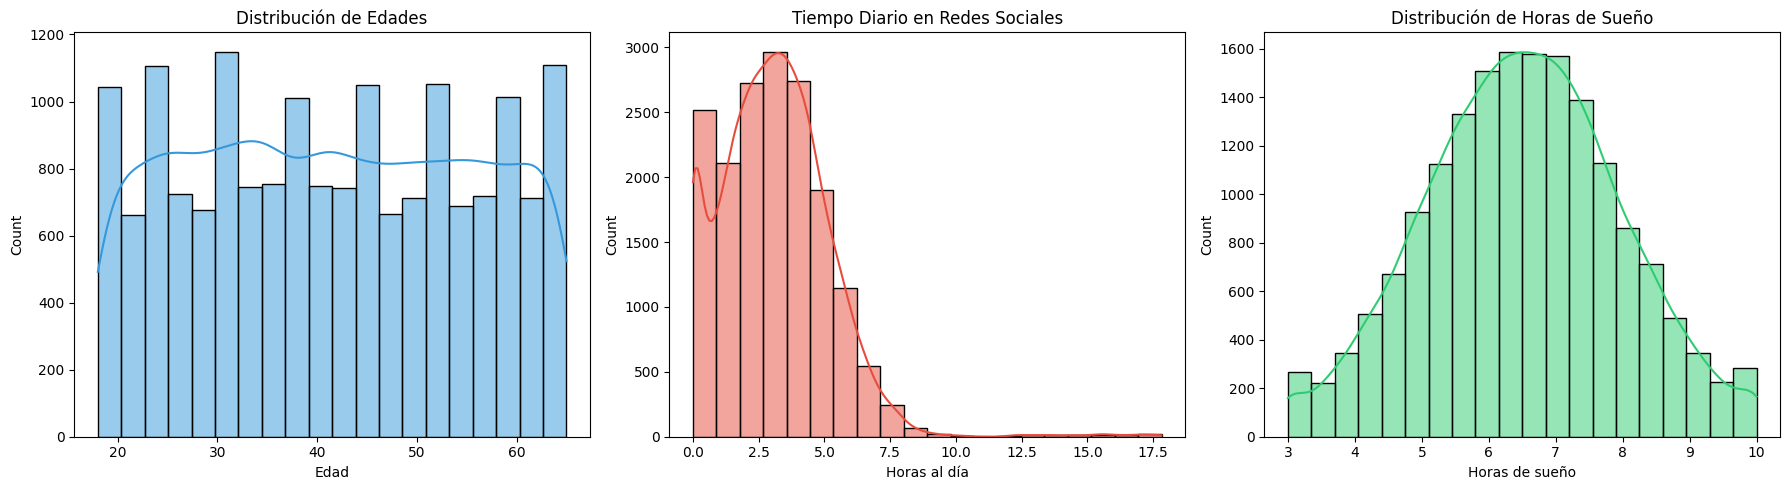

In [26]:
# Un vistazo rápido a las distribuciones clave del dataset
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gráfico 1: Edad
sns.histplot(smp_limpio['edad'], bins=20, kde=True, ax=axes[0], color='#3498db')
axes[0].set_title('Distribución de Edades')
axes[0].set_xlabel('Edad')

# Gráfico 2: Tiempo en Redes
sns.histplot(smp_limpio['tiempo_diario_redes_sociales'], bins=20, kde=True, ax=axes[1], color='#e74c3c')
axes[1].set_title('Tiempo Diario en Redes Sociales')
axes[1].set_xlabel('Horas al día')

# Gráfico 3: Horas de Sueño
sns.histplot(smp_limpio['horas_sueno'], bins=20, kde=True, ax=axes[2], color='#2ecc71')
axes[2].set_title('Distribución de Horas de Sueño')
axes[2].set_xlabel('Horas de sueño')

plt.tight_layout()
plt.show()

# ASIGNACIÓN DE GENERACIONES POR EDAD

In [17]:
def asignar_generacion(edad):
    if edad <= 26: return 'Gen Z/Alfa'
    elif 27 <= edad <= 42: return 'Millennial'
    elif 43 <= edad <= 58: return 'Gen X'
    else: return 'Boomer'

smp_limpio['generacion'] = smp_limpio['edad'].apply(asignar_generacion)

generacion
Millennial    5844
Gen X         5569
Gen Z/Alfa    3150
Boomer        2511
Name: count, dtype: int64


C:\Users\bootr\AppData\Local\Temp\ipykernel_11356\2181332327.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=smp_limpio, x='generacion', order=orden_generaciones, palette='viridis')


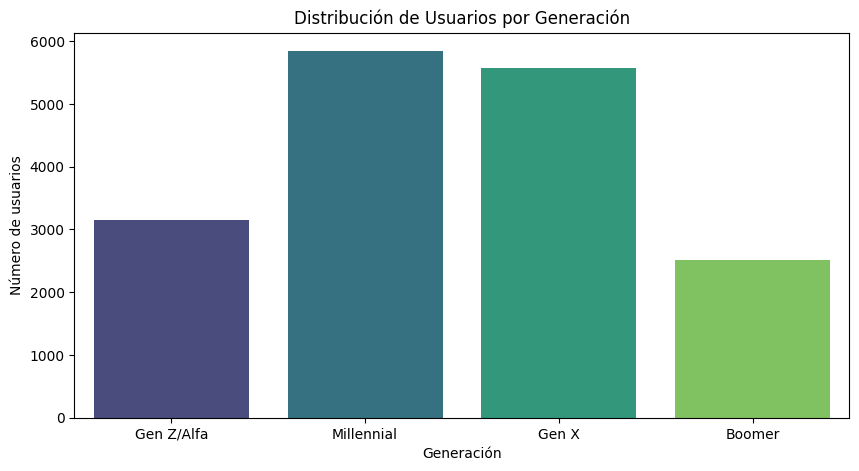

In [18]:
print(smp_limpio['generacion'].value_counts())

plt.figure(figsize=(10, 5))
orden_generaciones = ['Gen Z/Alfa', 'Millennial', 'Gen X', 'Boomer']
sns.countplot(data=smp_limpio, x='generacion', order=orden_generaciones, palette='viridis')
plt.title('Distribución de Usuarios por Generación')
plt.ylabel('Número de usuarios')
plt.xlabel('Generación')
plt.show()

# # ANÁLISIS DE HIPÓTESIS: TRANSVERSALIDAD DEL ESTRÉS

C:\Users\bootr\AppData\Local\Temp\ipykernel_11356\649391928.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smp_limpio, x='generacion', y='nivel_estres', order=orden_generaciones, palette='viridis', errorbar='ci')


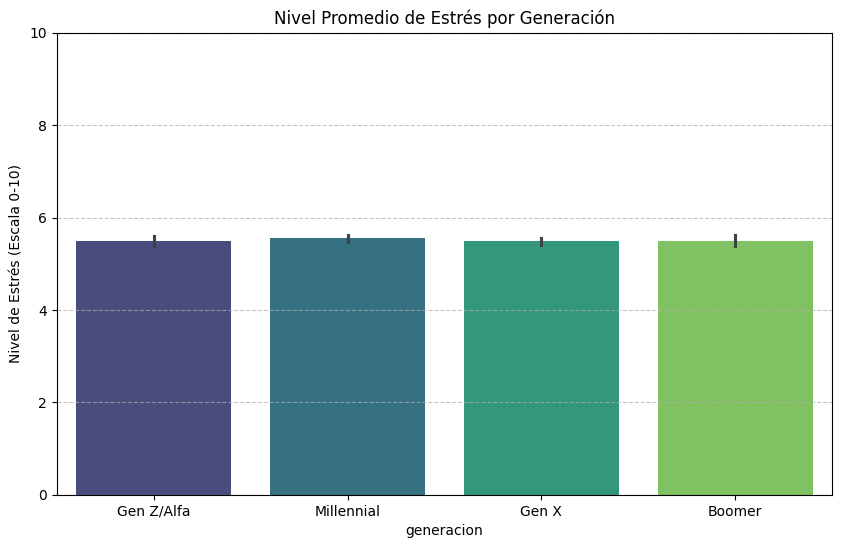

In [28]:

columnas_interes =['nivel_estres', 'horas_sueno', 'tiempo_diario_redes_sociales', 'dias_burnout_mes']
resumen_stats = smp_limpio.groupby('generacion')[columnas_interes].mean()
orden_generaciones = ['Gen Z/Alfa', 'Millennial', 'Gen X', 'Boomer']


plt.figure(figsize=(10, 6))
sns.barplot(data=smp_limpio, x='generacion', y='nivel_estres', order=orden_generaciones, palette='viridis', errorbar='ci')
plt.title('Nivel Promedio de Estrés por Generación')
plt.ylabel('Nivel de Estrés (Escala 0-10)')
plt.ylim(0, 10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Análisis de los datos:
Al observar los promedios, vemos que la diferencia entre la generación más estresada (Millennials: 5.55) y la menos estresada (Gen X: 5.48) es de apenas 0.06 puntos.
Conclusión técnica:
Esto explica por qué el Mapa de Correlación se veía "gris": matemáticamente, la relación entre edad y estrés es casi inexistente. El malestar digital no discrimina por año de nacimiento; es un fenómeno que afecta a todos por igual en la muestra. La Hipótesis 1 y 2 quedan oficialmente refutadas.

# # HALLAZGO FINAL: EL BIENESTAR DIGITAL COMO FACTOR PROTECTOR

Estrés según Bienestar Digital activado:
 bienestar_digital_activado
False    5.542886
True     5.419470
Name: nivel_estres, dtype: float64


C:\Users\bootr\AppData\Local\Temp\ipykernel_11356\2458080132.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=smp_limpio, x='bienestar_digital_activado', y='nivel_estres', palette='magma', errorbar='ci')


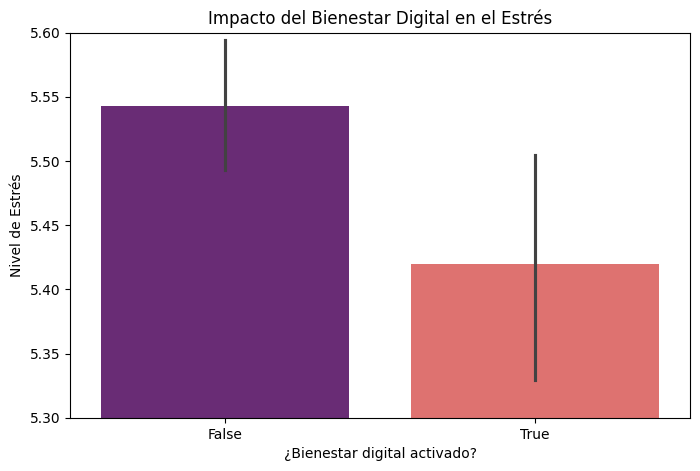

In [20]:

impacto = smp_limpio.groupby('bienestar_digital_activado')['nivel_estres'].mean()
print("Estrés según Bienestar Digital activado:\n", impacto)

plt.figure(figsize=(8, 5))
sns.barplot(data=smp_limpio, x='bienestar_digital_activado', y='nivel_estres', palette='magma', errorbar='ci')
plt.title('Impacto del Bienestar Digital en el Estrés')
plt.xlabel('¿Bienestar digital activado?')
plt.ylabel('Nivel de Estrés')
plt.ylim(5.3, 5.6)
plt.show()

Análisis de los datos:
Aquí encontramos el dato más importante del estudio. Activar el Bienestar Digital reduce el estrés de 5.54 a 5.41.
Conclusión técnica:
La diferencia (0.123) es el doble de grande que la diferencia entre generaciones. Esto demuestra que el estrés no es algo que "tienes" por tu edad, sino algo que "gestionas" con tus herramientas. Es más efectivo activar el Bienestar Digital que cambiar de generación.

# CONCLUSIONES DEL INFORME
- **Sobre las Generaciones:** Se ha demostrado que el nivel de estrés no es una variable dependiente de la edad. La transversalidad del estrés digital sugiere que estamos ante un problema de diseño tecnológico y hábitos de uso, no de brecha generacional.
- **Sobre las Soluciones:** La variable `bienestar_digital_activado` presenta una correlación positiva con la reducción del estrés. Recomendamos priorizar la educación en el uso de estas herramientas por encima de enfoques segmentados por edad.

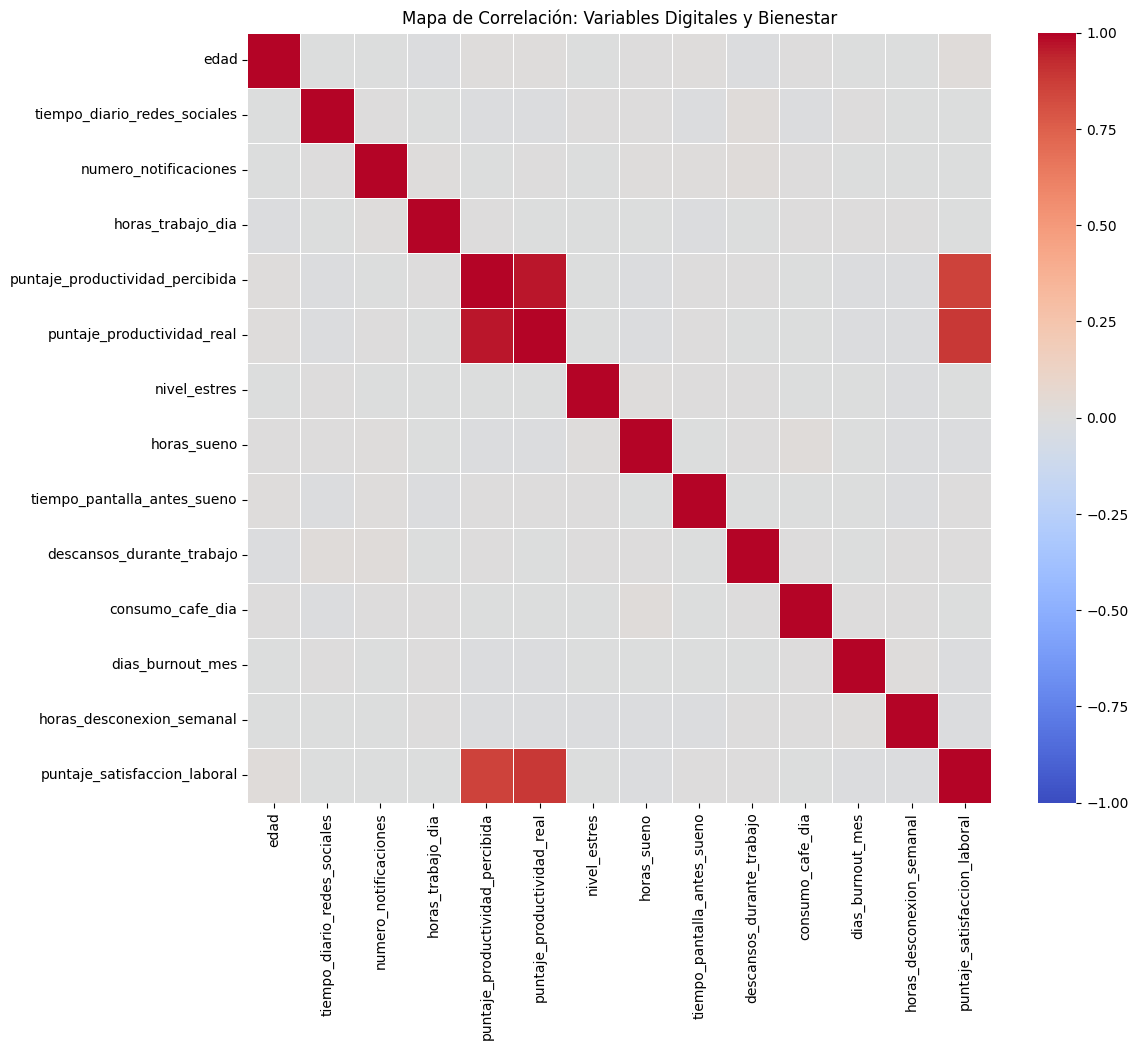

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la matriz de correlación (solo con columnas numéricas)
corr_matrix = smp_limpio.select_dtypes(include=[np.number]).corr()

# 2. Creamos el mapa de calor con el rango definido (-1 a 1)
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, 
            annot=False,          # Ponemos False para que no se sature de números
            cmap='coolwarm',      # 'coolwarm' es el estándar para rangos -1 a 1 (azul a rojo)
            vmin=-1, vmax=1,      # Aquí fijamos los límites exactos
            center=0,             # El centro (blanco) será el 0
            linewidths=.5)

plt.title('Mapa de Correlación: Variables Digitales y Bienestar')
plt.savefig('heatmap_correlacion.png', dpi=300, bbox_inches='tight')
plt.show()

Análisis de Correlación (Conclusión):
"La matriz de correlación muestra coeficientes cercanos a cero entre la edad y los niveles de malestar. Esto es un hallazgo crítico: rompe el mito de que el tiempo en redes sociales o la edad del usuario dictan por sí solos el nivel de estrés. El bienestar digital es un fenómeno complejo que no se explica de forma lineal; esto valida nuestra observación anterior de que el estrés es transversal y requiere un enfoque basado en hábitos (como el Bienestar Digital) y no en demografía."

C:\Users\bootr\AppData\Local\Temp\ipykernel_11356\4182337932.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=['No activado', 'Activado'], y=[media_no, media_si],


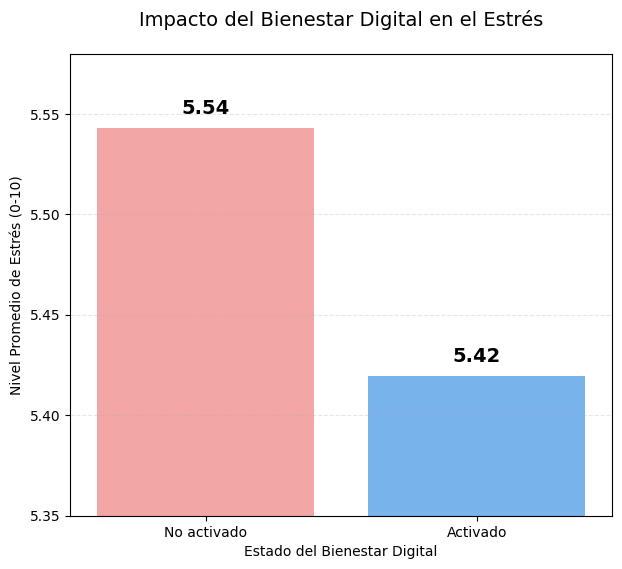

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos las medias
medias = smp_limpio.groupby('bienestar_digital_activado')['nivel_estres'].mean()
media_no = medias[False]
media_si = medias[True]

# 2. Creamos el gráfico
plt.figure(figsize=(7, 6))

# Usamos barplot
ax = sns.barplot(x=['No activado', 'Activado'], y=[media_no, media_si], 
                 palette=['#ff9999', '#66b3ff'], errorbar=None)

# 3. Añadimos el valor exacto sobre cada barra
for i, v in enumerate([media_no, media_si]):
    ax.text(i, v + 0.005, f'{v:.2f}', ha='center', va='bottom', fontsize=14, fontweight='bold')

# 4. Ajustamos el eje Y para hacer "zoom" y ver la diferencia
plt.ylim(5.35, 5.58) 

# 5. Títulos y etiquetas
plt.title('Impacto del Bienestar Digital en el Estrés', fontsize=14, pad=20)
plt.ylabel('Nivel Promedio de Estrés (0-10)')
plt.xlabel('Estado del Bienestar Digital')
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()

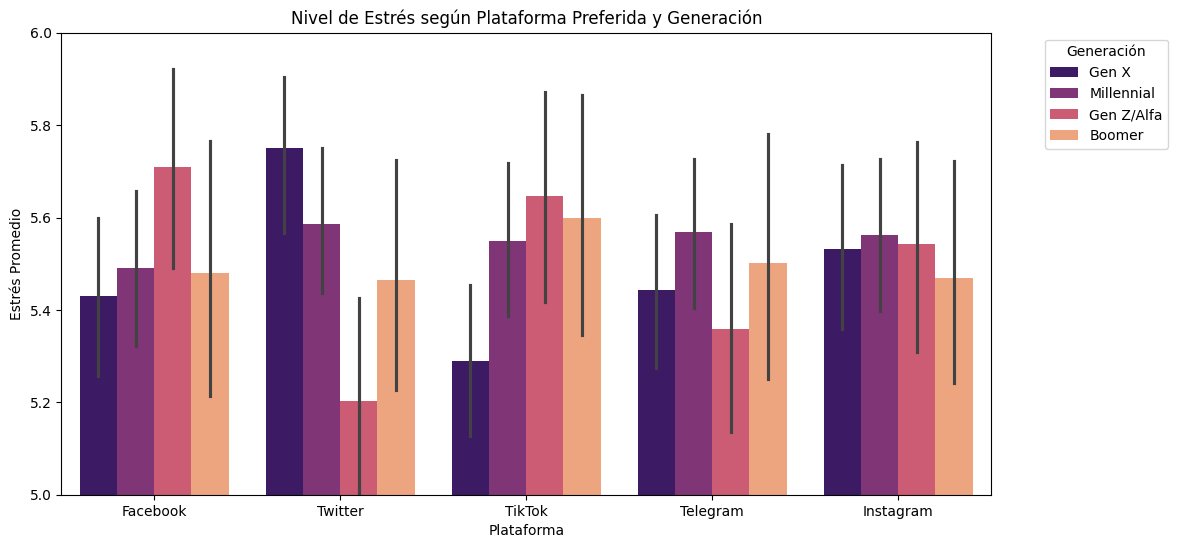

In [25]:
plt.figure(figsize=(12, 6))
sns.barplot(data=smp_limpio, x='plataforma_preferida', y='nivel_estres', hue='generacion', palette='magma')
plt.title('Nivel de Estrés según Plataforma Preferida y Generación')
plt.ylabel('Estrés Promedio')
plt.xlabel('Plataforma')
plt.legend(title='Generación', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.ylim(5, 6) 
plt.show()

Análisis de los datos (Gen Z/Alfa):
Sorprendentemente, para los más jóvenes, Facebook (5.71) es más estresante que TikTok (5.65).
Conclusión técnica:
Esto sugiere que la "toxicidad" no depende solo del algoritmo de moda, sino de cómo la plataforma interactúa con el usuario. El hecho de que Facebook (una red "antigua") sea la más estresante para la Gen Z abre una nueva línea de investigación sobre el conflicto de uso de redes no nativas.

#  CONCLUSIONES FINALES


El mito de la Gen Z: Los datos no apoyan la idea de que los jóvenes estén más estresados por las redes que sus padres o abuelos.
Acción sobre Demografía: Las campañas de salud mental digital deberían dejar de segmentar por edad y empezar a segmentar por configuración de herramientas (Bienestar Digital).
Independencia de Variables: La falta de correlación lineal (el mapa gris) nos dice que el estrés digital es multicausal. No se arregla solo durmiendo más o borrando una App; es una combinación de hábitos.